# Cutting-edge QFun: full research walkthrough

This notebook is a **deep-dive research notebook** for the upgraded QFun stack.

You will see how the new modules connect into one coherent paper story:

- **Architecture upgrades:** edge-level activations (KAN-style), multiplicative nodes, adaptive growth.
- **Optimization upgrades:** progressive grid refinement (qubit scaling), quantum-information regularization.
- **Verification upgrades:** Born-rule measurement agreement and hybrid quantum/classical inference.
- **Scientific analysis upgrades:** interpretability pipeline, theoretical diagnostics, and compact multi-seed ablation.

The guiding idea is that QFun stays **classically trainable** while remaining **quantum-structured**: activation profiles are constrained by amplitude/Born-rule constructions and can be physically measured.

---

## How to use this notebook

- Run top-to-bottom once to get a complete picture.
- Most sections are lightweight demos; a few are intentionally gated with boolean flags (`RUN_FULL_ABLATION`, `RUN_ADAPTIVE`) because they can be slow.
- Every section includes both **what the code does** and **how to interpret the result** for paper writing.

---

## Prerequisites

Install from the repo root so imports resolve correctly:

- `pip install -e .`

Optional acceleration:

- install JAX + Optax for larger training runs (`use_jax=True` in configs).

The first code cell also guards `sys.path` so this notebook works when opened from `notebooks/`.

In [1]:
import sys
from pathlib import Path

for _p in (Path.cwd(), Path.cwd().parent):
    if (_p / "qfun").is_dir():
        _root = str(_p.resolve())
        if _root not in sys.path:
            sys.path.insert(0, _root)
        break

import numpy as np
import matplotlib.pyplot as plt

## 1. Shared setup: Iris + baseline `QuantumActivationClassifier`

We first train a compact baseline model and use it as the common reference object across later sections.

### Why this matters

Many later analyses (measurement verification, interpretability, hybrid inference, grid refinement) need a trained model with learned activation profiles. Using one shared baseline keeps comparisons consistent.

### What happens in the next code cell

- Load and standardize Iris.
- Train a small QFun classifier (`standard` mode).
- Report train/test accuracy.
- Plot the training loss.

### How to read the output

- **Loss should trend down**: optimization is working.
- **Train/test gap**: rough overfitting indicator.
- This model is not tuned for SOTA accuracy here; it is a scaffold for investigating the new cutting-edge features.

Training 40 epochs (logging every 10)…
  epoch 10/40  train_loss=0.330845
  epoch 20/40  train_loss=0.166158
  epoch 30/40  train_loss=0.085015
  epoch 40/40  train_loss=0.049478
train acc: 1.0 test acc: 0.9473684210526315


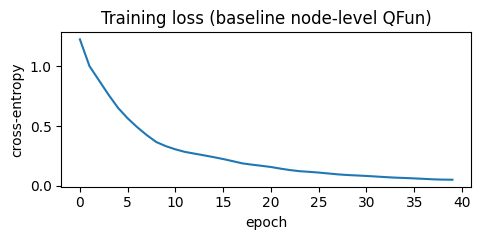

In [2]:
from qfun.datasets import load_classification_dataset, prepare_classification_split
from qfun.qfan import (
    QuantumActivationConfig,
    QuantumActivationClassifier,
    train_quantum_activation_classifier,
)

data_seed = 42
iris = load_classification_dataset("iris")
split = prepare_classification_split(
    iris,
    test_size=0.25,
    seed=data_seed,
    standardize=True,
)

cfg_base = QuantumActivationConfig(
    input_dim=split.x_train.shape[1],
    hidden_units=4,
    n_qubits=3,
    n_classes=len(split.target_names),
    mode="standard",
    learning_rate=0.05,
    steps=40,
    seed=data_seed,
    profile_interp="linear",
)

model, losses = train_quantum_activation_classifier(
    split.x_train,
    split.y_train,
    cfg_base,
    log_every=10,
)

print(
    "train acc:", model.accuracy(split.x_train, split.y_train),
    "test acc:", model.accuracy(split.x_test, split.y_test),
)

fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(losses)
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy")
ax.set_title("Training loss (baseline node-level QFun)")
plt.tight_layout()
plt.show()

## 2. Progressive grid refinement (KAN-style resolution / Hilbert space growth)

This section demonstrates the QFun analogue of KAN grid extension.

### Core concept

Increasing `n_qubits` increases activation-grid resolution from `2^n` to `2^(n+k)`. In quantum language, this is an expansion of representational capacity in Hilbert space.

### What `refine_classifier_grid` does

- Interpolates each learned activation profile from the old grid to the new grid.
- Updates internal model state (`n_qubits`, `num_grid_points`, activation grid, profile tensors).
- Preserves the learned coarse structure while enabling finer detail.

### Why this is useful

- Coarse-to-fine schedules are often easier to optimize than starting at max resolution.
- It gives a clear optimization narrative for paper writing: **learn global shape first, refine local detail later**.

### How to interpret the plot

- The coarse points show what the model previously knew.
- The refined curve shows a smooth continuation at higher resolution.
- Large distortions would suggest unstable interpolation; small/smooth changes are expected.

n_qubits: 3 -> 5 | grid: 8 -> 32


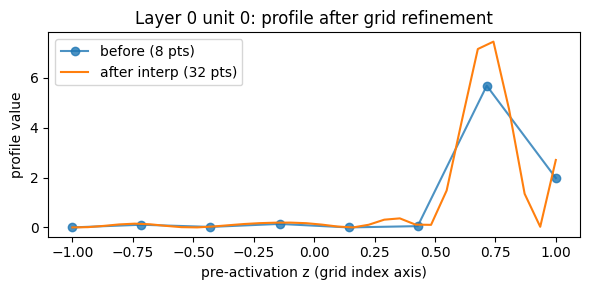

Example schedule: total epochs 90 | refinement at epochs [30, 60]


In [3]:
from qfun.qfan.grid_refinement import ProgressiveGridSchedule, refine_classifier_grid

prof_before = np.asarray(model.get_activation_profile(0, 0), dtype=float)
nq_old = model.n_qubits
refine_classifier_grid(model, nq_old + 2)
prof_after = np.asarray(model.get_activation_profile(0, 0), dtype=float)

print("n_qubits:", nq_old, "->", model.n_qubits, "| grid:", prof_before.size, "->", prof_after.size)

xg_old = np.linspace(-1.0, 1.0, prof_before.size)
xg_new = np.linspace(-1.0, 1.0, prof_after.size)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(xg_old, prof_before, "o-", label=f"before ({prof_before.size} pts)", alpha=0.8)
ax.plot(xg_new, prof_after, "-", label=f"after interp ({prof_after.size} pts)")
ax.set_xlabel("pre-activation z (grid index axis)")
ax.set_ylabel("profile value")
ax.legend()
ax.set_title("Layer 0 unit 0: profile after grid refinement")
plt.tight_layout()
plt.show()

sched = ProgressiveGridSchedule([(3, 30), (4, 30), (5, 30)])
print("Example schedule: total epochs", sched.total_epochs, "| refinement at epochs", sched.refinement_epochs())

## 3. Quantum information regularization (entropy, purity, fidelity diversity)

These regularizers are one of the strongest research differentiators in this notebook.

### Intuition

Activation profiles in QFun are not arbitrary lookup vectors; they come from quantum-style amplitude constructions. That lets us regularize with physically meaningful quantities:

- **Entropy**: controls profile information content (avoid too-peaky or too-flat behavior).
- **Purity**: controls concentration/coherence-like behavior.
- **Fidelity diversity**: discourages hidden units from collapsing to nearly identical profiles.

### Why this matters for a paper

Classical KAN usually uses geometric smoothness or sparsity penalties. Here you can claim an additional quantum-structured prior that is principled and interpretable.

### Practical usage

The code cell computes these values on the current model to inspect scale. For full training integration, add `compute_qi_regularization(...)` directly into the loss function with tunable weights.

In [4]:
from qfun.qfan import (
    von_neumann_entropy,
    quantum_fidelity,
    compute_qi_regularization,
)

raw0 = model.raw_profiles_layers[0][0]
raw1 = model.raw_profiles_layers[0][1]
print("von Neumann entropy (layer0 u0):", float(von_neumann_entropy(raw0)))
print("fidelity u0 vs u1:", float(quantum_fidelity(raw0, raw1)))
print(
    "combined QI penalty (demo weights):",
    float(
        compute_qi_regularization(
            model,
            entropy_weight=0.05,
            purity_weight=0.05,
            diversity_weight=0.05,
        )
    ),
)

von Neumann entropy (layer0 u0): 2.16810684097398
fidelity u0 vs u1: 0.10741596888306303
combined QI penalty (demo weights): 0.08119615715475041


## 4. Born-rule measurement verification

`verify_all_profiles` prepares learned amplitudes and compares sampled histograms to exact profiles (KL, TV, Hellinger).

In [5]:
from qfun.qfan import verify_all_profiles, print_verification_summary

report = verify_all_profiles(model, shots=3000)
print_verification_summary(report)


Measurement Verification Report
  Mode: standard
  Qubits: 5 (32 grid points)
  Profiles verified: 4

Layer Unit       KL       TV     Hell     Corr   MaxErr
-------------------------------------------------------
    0    0   0.0226   0.0225   0.0414   0.9994   0.2709
    0    1   0.0043   0.0250   0.0295   0.9991   0.2526
    0    2   0.0108   0.0263   0.0363   0.9993   0.4282
    0    3   0.0167   0.0223   0.0410   0.9992   0.1751

Aggregated:
  Mean KL divergence:     0.013592
  Mean total variation:   0.024012
  Mean Hellinger:         0.037027


## 5. Interpretability: taxonomy, importance, pruning, clusters

Classify shapes vs reference activations, rank units by outgoing weights, simulate pruning, and cluster profiles in profile space.

In [6]:
from qfun.qfan import (
    classify_all_profiles,
    compute_importance_scores,
    evaluate_pruning,
    cluster_profiles,
    print_taxonomy_summary,
    print_importance_summary,
    print_pruning_summary,
    print_cluster_summary,
)

taxonomy = classify_all_profiles(model, novelty_threshold=0.7)
print_taxonomy_summary(taxonomy)

imp = compute_importance_scores(model)
print_importance_summary(imp)

prune = evaluate_pruning(model, split.x_test, split.y_test, prune_fraction=0.25)
print_pruning_summary(prune)

clusters = cluster_profiles(model, n_clusters=3)
print_cluster_summary(clusters)


Activation Profile Taxonomy
------------------------------------------------------------
Layer Unit   Best Match Similarity  Novel
-----------------------------------------
    0    0         relu     0.6423      *
    0    1    soft_step     0.5144      *
    0    2         relu     0.5573      *
    0    3     gaussian     0.6618      *

Type distribution:
  relu: 2
  soft_step: 1
  gaussian: 1
  Novel profiles: 4/4

Unit Importance Scores
--------------------------------------------------
Layer Unit  Weight Norm  Rel. Imp.
----------------------------------
    0    3       1.5392     1.0000
    0    0       1.4641     0.9512
    0    2       0.9643     0.6265
    0    1       0.8722     0.5667

Pruning Analysis
  Fraction pruned:    25.0%
  Units pruned:       1
  Units retained:     3
  Original accuracy:  0.7895
  Pruned accuracy:    0.7632
  Accuracy drop:      0.0263

Profile Clusters (3 clusters)
--------------------------------------------------
  Cluster 0: 2 members (mean 

## 6. Hybrid inference: classical table vs finite-shot quantum readout

Now we compare two inference pathways on the same trained model:

- **Classical inference**: exact interpolation on learned profiles.
- **Quantum inference**: profiles reconstructed from finite-shot measurements.

### Why this section is important

This experimentally links model behavior to real measurement constraints.

If shot count increases and quantum inference converges toward classical predictions, that is strong evidence for practical quantum realizability.

### What to watch

- Accuracy gap (`classical - quantum`)
- Prediction agreement rate
- Convergence trend as shots increase

In [7]:
from qfun.qfan import compare_inference_modes, shot_convergence_analysis, print_convergence_summary

cmp = compare_inference_modes(
    model,
    split.x_test,
    split.y_test,
    shots=4000,
    max_samples=30,
)
print(
    "classical acc:", cmp.classical_accuracy,
    "quantum acc:", cmp.quantum_accuracy,
    "pred agreement:", cmp.agreement_rate,
)

conv = shot_convergence_analysis(
    model,
    split.x_test,
    split.y_test,
    shot_counts=[500, 2000, 8000],
    max_samples=20,
)
print_convergence_summary(conv)

classical acc: 0.7333333333333333 quantum acc: 0.7666666666666667 pred agreement: 0.9666666666666667

Shot-Budget Convergence Analysis
Classical accuracy: 0.6500

   Shots   Q-Accuracy    Agreement        Gap
---------------------------------------------
     500       0.6000       0.9500     0.0500
    2000       0.7000       0.9500    -0.0500
    8000       0.6000       0.9500     0.0500

Final gap at 8000 shots: 0.0500


## 7. Edge-level classifier (KAN-style per-edge profiles)

This is the architectural jump from node-level to edge-level activations.

### Node-level vs edge-level

- **Node-level (baseline):** one profile per hidden unit.
- **Edge-level:** each input-to-hidden connection learns its own profile `phi_ij`.

This is closer to the original KAN spirit (`sum_i phi_ij(x_i)`) and increases expressivity.

### Variants

- `activation_level="edge"`: fully independent edge profiles.
- `activation_level="shared_edge"`: shared parent profile + per-edge affine transforms (parameter-efficient, GS-KAN-style).

### Reading results

Compare test accuracy and inspect individual edge profiles to see whether edges specialize into distinct functional roles.

  epoch 10/35  loss=0.278594
  epoch 20/35  loss=0.102424
  epoch 30/35  loss=0.057675
  epoch 35/35  loss=0.047118
edge-level test acc: 0.9473684210526315


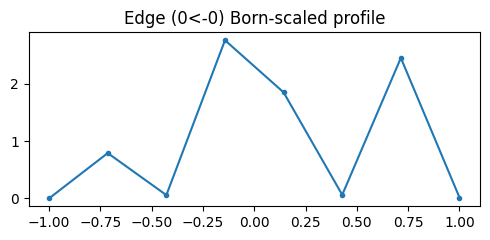

In [8]:
from qfun.qfan import EdgeLevelConfig, train_edge_level_classifier

edge_cfg = EdgeLevelConfig(
    input_dim=split.x_train.shape[1],
    hidden_layers=(5,),
    n_qubits=3,
    n_classes=len(split.target_names),
    mode="standard",
    activation_level="edge",
    learning_rate=0.03,
    steps=35,
    seed=1,
)

edge_model, edge_losses = train_edge_level_classifier(
    split.x_train,
    split.y_train,
    edge_cfg,
    log_every=10,
)

print(
    "edge-level test acc:",
    edge_model.accuracy(split.x_test, split.y_test),
)
prof_edge = edge_model.get_edge_profile(0, 0, 0)
fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(np.linspace(-1, 1, len(prof_edge)), prof_edge, ".-")
ax.set_title("Edge (0<-0) Born-scaled profile")
plt.tight_layout()
plt.show()

## 8. MultQFun: multiplicative + additive edges (physics-friendly)

Many scientific equations are inherently multiplicative (e.g., products, ratios). This section adds that structure directly.

### Mechanism

For each hidden unit:

- first `n_multiplicative` edge activations are multiplied,
- remaining edge activations are summed,
- then bias/output projection follows.

### Why this helps

Without multiplicative nodes, additive architectures may need extra depth to emulate simple products. MultQFun can represent those patterns more directly and often more efficiently.

The synthetic target in the next cell (`x0*x1 + 0.5*x2`) is intentionally chosen to visualize this benefit.

  epoch 20/80  mse=0.068236
  epoch 40/80  mse=0.064363
  epoch 60/80  mse=0.064043
  epoch 80/80  mse=0.063990
final MSE (train, sample): 0.07169332465012353


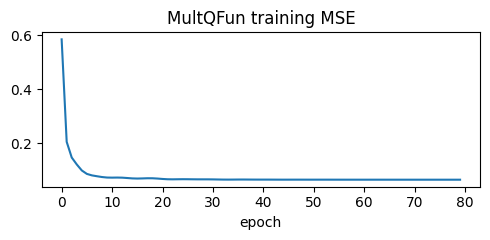

In [9]:
from qfun.qfan import MultQFunConfig, train_multqfun

rng = np.random.default_rng(0)
n_samp = 400
x_reg = rng.uniform(-0.7, 0.7, size=(n_samp, 3))
y_reg = (x_reg[:, 0] * x_reg[:, 1] + 0.5 * x_reg[:, 2]).reshape(-1, 1)

m_cfg = MultQFunConfig(
    input_dim=3,
    hidden_layers=(6,),
    n_qubits=3,
    n_classes=1,
    mode="standard",
    n_multiplicative=2,
    learning_rate=0.02,
    steps=80,
    seed=0,
)
m_model, m_losses = train_multqfun(x_reg, y_reg, m_cfg, log_every=20)
pred = m_model.predict(x_reg[:50])
print("final MSE (train, sample):", float(np.mean((pred - y_reg[:50]) ** 2)))

fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(m_losses)
ax.set_title("MultQFun training MSE")
ax.set_xlabel("epoch")
plt.tight_layout()
plt.show()

## 9. Theory helpers: discretization error, Born regularization, parameter counts

This section supports theory claims with reproducible diagnostics.

### Included analyses

1. **Approximation error vs grid size**
   - Empirical proxy for universality/expressivity trends.
   - Expect error to decrease as `n_qubits` (grid resolution) increases.

2. **Born-rule constraint analysis**
   - Compares profile statistics under Born-structured sampling.
   - Useful for arguing implicit regularization from quantum constraints.

3. **Parameter-count comparisons**
   - Side-by-side counts for MLP, KAN-like, and QFun variants.
   - Useful for fairness discussions in benchmark tables.

These outputs are designed to be directly transferrable into a methods/theory section draft.

In [10]:
from qfun.qfan import (
    approximation_error_vs_grid_size,
    born_rule_constraint_analysis,
    parameter_count_comparison,
    print_approximation_error_table,
    print_born_rule_analysis,
    print_parameter_comparison,
)

errs = approximation_error_vs_grid_size(np.sin, n_qubits_range=[2, 3, 4, 5, 6])
print_approximation_error_table(errs)

born = born_rule_constraint_analysis(n_qubits_range=[3, 4, 5])
print_born_rule_analysis(born)

counts = parameter_count_comparison(
    input_dim=4,
    output_dim=3,
    hidden_widths=[6, 6],
    n_qubits=4,
)
print_parameter_comparison(counts)


Approximation Error vs Grid Size
-------------------------------------------------------
 NQ     G     L2 Error   Linf Error    Rel Error
------------------------------------------------
  2     4     0.020311     0.034205     0.024138
  3     8     0.003861     0.007704     0.004589
  4    16     0.000846     0.001785     0.001005
  5    32     0.000198     0.000428     0.000236
  6    64     0.000048     0.000105     0.000057

Born Rule Constraint Analysis
----------------------------------------------------------------------
 NQ     G   DoF  Born Smooth    Unconstr.   Mean H    Max H
-----------------------------------------------------------
  3     8     7     0.051222     0.011763   1.4577   2.0794
  4    16    15     0.014060     0.002754   2.0994   2.7726
  5    32    31     0.003758     0.000671   2.7585   3.4657

Parameter Count Comparison
--------------------------------------------------
          Model Total Params
----------------------------
            MLP           93

## 10. Multi-seed ablation (compact)

Ablations are where the paper-quality evidence is built.

### Why multi-seed

Single-seed gains are often noisy. Multi-seed mean/std gives a stability story and makes claims credible.

### What this section runs

A compact grid over mode, qubits, and width (configurable), then prints a clean table.

### Recommended workflow

- Start with this compact run to validate pipeline.
- Expand to larger dataset grids after confirming runtime.
- Export and archive tables/JSON for reproducibility in the paper appendix.

In [ ]:
from qfun.qfan import run_multi_seed_ablation, print_ablation_table

RUN_FULL_ABLATION = True  # set True for a paper-style table (slow)

if RUN_FULL_ABLATION:
    runs, cells = run_multi_seed_ablation(
        "iris",
        modes=["standard", "mode_a"],
        n_qubits_list=[3, 4],
        hidden_units_list=[4, 6],
        profile_interp_list=["linear"],
        seeds=[42, 43],
        steps=50,
        use_jax=False,
        log_every=25,
    )
    print_ablation_table(cells, dataset="iris")
else:
    print("Set RUN_FULL_ABLATION = True to run a small multi-seed grid on Iris.")


[1/8] iris | mode=standard nq=3 hu=4 pi=linear
Training 50 epochs (logging every 25)…
  epoch 25/50  train_loss=0.094249
  epoch 50/50  train_loss=0.023433
Training 50 epochs (logging every 25)…
  epoch 25/50  train_loss=0.075244
  epoch 50/50  train_loss=0.020224
    acc=0.9444+/-0.0333 f1=0.9436+/-0.0341

[2/8] iris | mode=standard nq=3 hu=6 pi=linear
Training 50 epochs (logging every 25)…
  epoch 25/50  train_loss=0.007101
  epoch 50/50  train_loss=0.001095
Training 50 epochs (logging every 25)…
  epoch 25/50  train_loss=0.017010
  epoch 50/50  train_loss=0.002163
    acc=0.9444+/-0.0333 f1=0.9436+/-0.0341

[3/8] iris | mode=standard nq=4 hu=4 pi=linear
Training 50 epochs (logging every 25)…
  epoch 25/50  train_loss=0.008976
  epoch 50/50  train_loss=0.000263
Training 50 epochs (logging every 25)…
  epoch 25/50  train_loss=0.067013
  epoch 50/50  train_loss=0.006827
    acc=0.9111+/-0.0222 f1=0.9120+/-0.0205

[4/8] iris | mode=standard nq=4 hu=6 pi=linear
Training 50 epochs (loggi

## 11. Adaptive growth (optional)

This section demonstrates a QFun analogue of adaptive ansatz growth.

### Idea

Instead of fixing architecture size upfront:

1. train a small model,
2. evaluate where adding capacity is most useful,
3. grow selected layer width,
4. continue training.

### Why this is interesting

- Better compute efficiency than over-parameterizing from epoch 0.
- Gives an optimization narrative aligned with adaptive quantum model design.
- Often improves interpretability because complexity is added only where needed.

Keep this optional flag off by default unless you want to profile longer runs.

In [ ]:
from qfun.qfan import AdaptiveGrowthConfig, adaptive_growth_train, print_growth_summary

RUN_ADAPTIVE = True  # set True to run (several training stages)

if RUN_ADAPTIVE:
    ag_cfg = AdaptiveGrowthConfig(
        input_dim=split.x_train.shape[1],
        n_classes=len(split.target_names),
        initial_hidden=(2,),
        max_hidden_per_layer=6,
        max_growth_steps=2,
        n_qubits=3,
        mode="standard",
        epochs_per_stage=25,
        learning_rate=0.05,
        seed=9,
    )
    ag_result = adaptive_growth_train(
        split.x_train,
        split.y_train,
        split.x_test,
        split.y_test,
        ag_cfg,
        log_every=10,
    )
    print_growth_summary(ag_result)
    print(
        "final test acc:",
        ag_result.final_model.accuracy(split.x_test, split.y_test),
    )
else:
    print("Set RUN_ADAPTIVE = True to run adaptive growth.")

TypeError: AdaptiveGrowthResult.__init__() missing 1 required positional argument: 'final_model'

## Final interpretation checklist (for paper writing)

Use this checklist to convert notebook results into manuscript claims:

- **Performance claim**: supported by multi-seed ablation means/std, not single runs.
- **Architecture claim**: compare node-level baseline vs edge-level and/or multiplicative variants.
- **Optimization claim**: show coarse-to-fine grid refinement behavior (stability + accuracy trend).
- **Quantum claim**: report measurement agreement metrics and hybrid inference convergence with shot count.
- **Interpretability claim**: include taxonomy distribution, pruning impact, and cluster examples.
- **Theory claim**: include approximation-vs-grid and parameter-scaling diagnostics.

If you plan a full benchmark campaign, run this notebook once in quick mode, then move to scripted experiments for reproducible large-scale sweeps.